In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

import pymc as pm
import pytensor.tensor as pt


In [3]:
PROJ_DIR = Path.cwd().parent
DATA_DIR = PROJ_DIR / "data"
SENT_DAT_DIR = DATA_DIR / "sent_data"
PROC_DAT_DIR = SENT_DAT_DIR / "processed"

In [4]:
# --> Load aggregated functioal response data 
# --> This data was used to build figure 2 in Nandini et al (2026)

fr = pd.read_csv(PROC_DAT_DIR / 'hoja1_functional_response.csv')

In [ ]:
N_REPLICATES = 4
SAL_LEVELS = [10, 20, 30]
N0   = fr['N0'].to_numpy(float)
ybar = fr['mean_consumed'].to_numpy(float)
se   = fr['se_consumed'].to_numpy(float)
n    = np.full(len(fr), N_REPLICATES, dtype='int32')   
sd_w = se * np.sqrt(n)


In [ ]:
prey_idx, prey = pd.factorize(fr['Prey_Type'])
prey_dix = prey_idx.astype('int32')
# Salinity is ordinal, so we'll proceed differently
sal_int = fr['Salinity'].str.extract(r'(\d+)')[0].astype(int)
sal_idx = pd.Categorical(
    sal_int, categories=SAL_LEVELS, ordered=True
    ).codes.astype('int32')

assert (prey_idx >= 0).all(), "NaN/unmapped prey slipped to -1"
assert (sal_idx  >= 0).all(), "salinity label outside {10, 20, 30}"
assert len(prey) == 3, f"expected 3 prey, got {list(prey)}"

coords = {
    "prey": list(prey), 
    "salinity": SAL_LEVELS, 
    "obs": np.arange(len(fr)),
    }

Holling disc equation:
$$\mu =  \frac{a \cdot N}{1+a \cdot h \cdot N}$$
where,
* $a$ is attack rate
* $h$ is handling time
* $N$ is consumption


The data generative process can be represented as follows:

<u>Indexing</u>:
* $i \in {1, 2, 3}$ - prey (Apo, Nito, Bp)
* $j \in {1, 2, 3}$ - salinity (10, 20, 30g/L)
* $k = K_{ij}$ - series of initial prey density offered
* $u$, $v$ - prey (i), salinity (j) main effect, respectively (for $\alpha$ and h)
* $w$ - prey $\times$  salinity interaction (ij) for both $\alpha$ and h
* $\alpha_{ij}$ - attack rate (low-density capture fraction) per cell
* $h_{ij}$ - handling time, per cell
* $N_{0,ijk}$ - offered prey density (data)
* $\mu_{ijk}$ - mean consumption, via $\mu=\frac{\alpha N_0}{1 + \alpha h N_0}$
* A_{ij} = 1 / $h_{ij}$ - asymptote, if you want the maximum-consuption number for reporting

In [ ]:
with pm.Model(coords=coords) as fr_model:
    # Everything that could be swapped at predict-time lives in pm.Data
    N0_     = pm.Data("N0",     N0,     dims="obs")     # predictor AND upper bound
    ybar_   = pm.Data("ybar",   ybar,   dims="obs")     # observed cell mean
    se_     = pm.Data("se",     se,     dims="obs")     # known SE (plain version)
    pix = pm.Data("prey_idx",  prey_idx,   dims='obs')
    six = pm.Data("sal_idx",    sal_idx,    dims='obs')  

    # --- low-density capture fraction alpha, in (0,1) ------------------------
    # BACKGROUND CONSTRAINT (not from this data): consumption cannot exceed prey
    # offered, so the low-density slope consumed/offered is a fraction in (0,1).
    # Hence the LOGIT scale; invlogit also forces mu < N0 by construction.
    #
    # a0: with ZeroSumNormal effects (sum to 0), the intercept is the GRAND MEAN
    #     logit capture fraction across all cells.
    #     Normal(0, 1.5) => median fraction 0.5, central 95% ~ (0.05, 0.95):
    #     an ignorance prior on a bounded fraction, symmetric, pre-data.

    a0 = pm.Normal('a0', mu=0, sigma=1.5)
    a_prey = pm.ZeroSumNormal('a_prey', sigma=1.0, dims='prey')
    a_sal = pm.ZeroSumNormal('a_sal', sigma=1.0, dims='salinity')
    # interaction: devaiation not explained by the two main effects
    # sum-to-zero on BOTH margins(n_zerosum_axes=2). Has a sigma lower 
    # than the main-effect sigma, it encodes a background lean toward 
    # additivity. This because interaction is a correction, expected to be
    # the smaller term until the data says otherwise.
    a_int = pm.ZeroSumNormal(
        'a_int', sigma=0.5, dims=('prey', 'salinity'), n_zerosum_axes=2)
    α = pm.Deterministic(
        'α', pm.math.invlogit(a0 + a_prey[pix] + a_sal[six] + a_int[pix, six]),
        dims='obs'
    )

    # handling time h > 0 -> log scale. Same (prey, salinity, interaction)
    # structure as the attack rate, because the DAG routes BOTH parameters
    # through the same prey/predator osmotic states: whatever lets salinity and
    # prey-identity (and their interaction) move a, moves h too.
    # Priors are background-only and DELIBERATELY TIGHTER than a's. 
    # Rationale is:
    #(i) this is a euryhaline species whose tested 10-30 g/L sits inside its 
    # 5-40 tolerance, so handling shifts are expected to be modest; 
    # (ii) the asymptote (1/h) is structurally weakly identified by 
    # sub-saturating curves, so we lean on background and will let psense 
    # report which h-effects are prior-driven rather than data-driven.
    h0 = pm.Normal('h0', np.log(1/40), 0.75) # grand-mean log handling time
    hp_prey = pm.ZeroSumNormal('hp_prey', sigma=0.5, dims='prey')
    hp_sal = pm.ZeroSumNormal('hp_sal', sigma=0.5, dims='salinity')
    hp_ax = pm.ZeroSumNormal(
        'hp_ax', sigma=0.3, dims=('prey', 'salinity'), n_zerosum_axes=2)
    h = pm.Deterministic(
        'h', pt.exp(h0 + hp_prey[pix] + hp_sal[six] + hp_ax[pix, six]),
        dims='obs'
        ) 
    pm.Deterministic('A', 1.0/h, dims='obs') # asymptote, per cell.

    # --- Holling type II disc equation, native (attack rate, handling time) form ---
    # μ = a * N0 / (1+ a * h * N0)

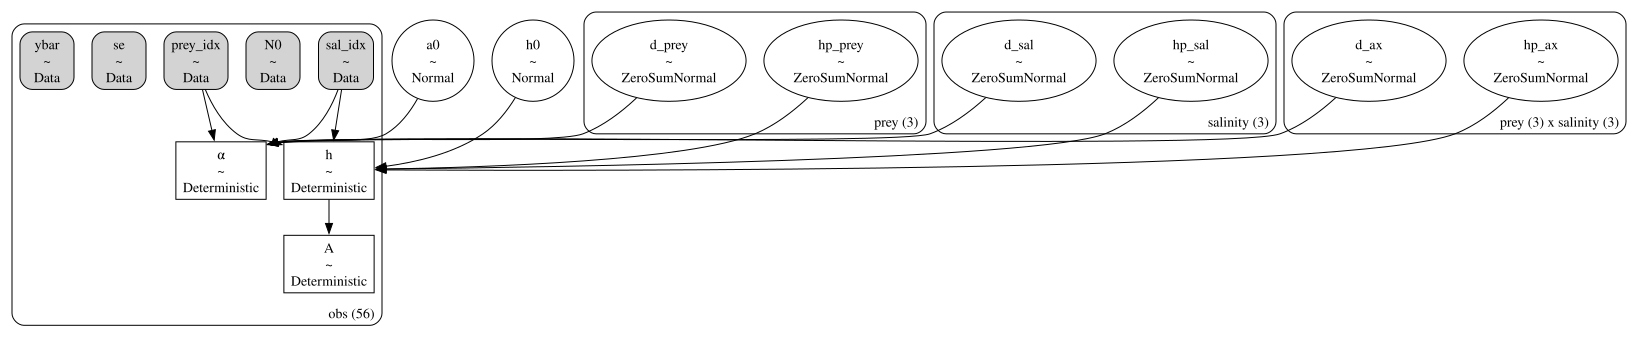

In [13]:
fr_model.to_graphviz()